## Part Technial & AI Plan - Proof of Data Loading in Python

In [ ]:
import pandas as pd

# URLs for all-state ZIP data (includes AGI)
url_2021 = "https://www.irs.gov/pub/irs-soi/21zpallagi.csv"
url_2016 = "https://www.irs.gov/pub/irs-soi/16zpallagi.csv"

# Load data
df_2021 = pd.read_csv(url_2021)
df_2016 = pd.read_csv(url_2016)

# Cleaning: Filter out state totals and calculate AGI per ZIP
def clean_soi(df):
    df = df[df['zipcode'] != 0] # Remove state totals
    # Group by ZIP and sum AGI (A00100) and Returns (N1)
    return df.groupby('zipcode')[['N1', 'A00100']].sum().reset_index()

summary_21 = clean_soi(df_2021)
summary_16 = clean_soi(df_2016)

# Calculate Booms and Shrinkage
comparison = summary_21.merge(summary_16, on='zipcode', suffixes=('_21', '_16'))
comparison['agi_growth'] = (comparison['A00100_21'] - comparison['A00100_16']) / comparison['A00100_16']

print(comparison[['zipcode', 'agi_growth']])

       zipcode  agi_growth
0         1001    0.244406
1         1002    0.348267
2         1005    0.338978
3         1007    0.250525
4         1008    0.186870
...        ...         ...
27533    99827    0.235004
27534    99833    0.360282
27535    99835    0.382972
27536    99901    0.168026
27537    99999    0.897507

[27538 rows x 2 columns]


In [ ]:
# Below is for reviewing the shape of the data and ensuring it loaded correctly. Not needed for final analysis.

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Example IRS SOI ZIP data URL for 2021 (update year as needed)
irs_url = 'https://www.irs.gov/pub/irs-soi/21zpallagi.csv'  # 2021 data

# Read directly from IRS website
try:
    irs_data = pd.read_csv(irs_url, dtype=str)
    print('IRS data loaded from URL')
except Exception as e:
    print('Could not load IRS data from URL:', e)
    irs_data = None

# Show shape and columns if loaded
if irs_data is not None:
    print(f'IRS Data Shape: {irs_data.shape}')
    print('Columns:', list(irs_data.columns))

IRS data loaded from URL
IRS Data Shape: (166221, 167)
Columns: ['STATEFIPS', 'STATE', 'zipcode', 'agi_stub', 'N1', 'mars1', 'MARS2', 'MARS4', 'ELF', 'CPREP', 'PREP', 'DIR_DEP', 'VRTCRIND', 'N2', 'TOTAL_VITA', 'VITA', 'TCE', 'VITA_EIC', 'RAC', 'ELDERLY', 'A00100', 'N02650', 'A02650', 'N00200', 'A00200', 'N00300', 'A00300', 'N00600', 'A00600', 'N00650', 'A00650', 'N00700', 'A00700', 'N00900', 'A00900', 'N01000', 'A01000', 'N01400', 'A01400', 'N01700', 'A01700', 'SCHF', 'N02300', 'A02300', 'N02500', 'A02500', 'N26270', 'A26270', 'N02900', 'A02900', 'N03220', 'A03220', 'N03300', 'A03300', 'N03270', 'A03270', 'N03150', 'A03150', 'N03210', 'A03210', 'N02910', 'A02910', 'N04450', 'A04450', 'N04100', 'A04100', 'N04200', 'A04200', 'N04470', 'A04470', 'A00101', 'N17000', 'A17000', 'N18425', 'A18425', 'N18450', 'A18450', 'N18500', 'A18500', 'N18800', 'A18800', 'N18460', 'A18460', 'N18300', 'A18300', 'N19300', 'A19300', 'N19500', 'A19500', 'N19530', 'A19530', 'N19550', 'A19550', 'N19570', 'A19570

In [6]:
# Preview the first few rows
if irs_data is not None:
    display(irs_data.head(10))

,STATEFIPS,STATE,zipcode,agi_stub,N1,mars1,MARS2,MARS4,ELF,CPREP,...,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
0,01,AL,00000,1,720280.0000,466930.0000,75840.0000,165330.0000,677820.0000,21700.0000,...,0.0000,0.0000,42310.0000,35969.0000,632780.0000,2182999.0000,630530.0000,2176448.0000,2290.0000,5215.0000
1,01,AL,00000,2,524160.0000,264900.0000,109720.0000,134980.0000,495550.0000,14170.0000,...,0.0000,0.0000,87370.0000,115842.0000,435160.0000,1402396.0000,432590.0000,1393449.0000,3100.0000,7423.0000
2,01,AL,00000,3,291860.0000,120090.0000,116380.0000,46410.0000,275270.0000,8580.0000,...,0.0000,0.0000,79750.0000,165576.0000,212390.0000,608660.0000,209210.0000,597461.0000,4110.0000,11648.0000
3,01,AL,00000,4,184320.0000,48650.0000,115740.0000,16120.0000,173910.0000,4010.0000,...,0.0000,0.0000,60450.0000,172959.0000,122910.0000,409261.0000,120020.0000,397318.0000,2690.0000,12922.0000
4,01,AL,00000,5,287720.0000,38750.0000,234070.0000,9640.0000,272240.0000,7750.0000,...,110.0000,34.0000,128440.0000,638854.0000,159690.0000,678251.0000,152450.0000,616679.0000,8440.0000,54805.0000
5,01,AL,00000,6,100370.0000,7990.0000,87330.0000,900.0000,95140.0000,1880.0000,...,54470.0000,319121.0000,61130.0000,1972695.0000,35890.0000,915287.0000,25290.0000,321928.0000,10510.0000,537831.0000
6,01,AL,35004,1,1320.0000,930.0000,180.0000,190.0000,1250.0000,30.0000,...,0.0000,0.0000,90.0000,100.0000,1110.0000,3139.0000,1110.0000,3079.0000,0.0000,0.0000
7,01,AL,35004,2,1360.0000,770.0000,230.0000,300.0000,1290.0000,40.0000,...,0.0000,0.0000,240.0000,228.0000,1110.0000,3092.0000,1100.0000,3012.0000,30.0000,58.0000
8,01,AL,35004,3,1000.0000,450.0000,330.0000,160.0000,960.0000,30.0000,...,0.0000,0.0000,230.0000,422.0000,760.0000,1936.0000,750.0000,1921.0000,0.0000,0.0000
9,01,AL,35004,4,600.0000,170.0000,340.0000,70.0000,570.0000,0.0000,...,0.0000,0.0000,210.0000,529.0000,390.0000,1187.0000,380.0000,1158.0000,30.0000,131.0000


In [9]:
# Clean and process the IRS data (find ZIP column dynamically, filter, convert columns)
if irs_data is not None:
    # Find ZIP code column (case-insensitive)
    zip_col = next((col for col in irs_data.columns if col.strip().lower() in ['zipcode', 'zip', 'zip_code', 'zcta'] or 'zip' in col.strip().lower()), None)
    state_col = next((col for col in irs_data.columns if col.strip().lower() in ['state', 'st'] or 'state' in col.strip().lower()), None)
    if zip_col is not None:
        # Remove summary/aggregate rows (e.g., ZIPs like 00000, 99999)
        irs_data = irs_data[~irs_data[zip_col].isin(['00000', '99999'])]
    else:
        print('⚠️ ZIP code column not found!')
    # Convert numeric columns (example: AGI, returns)
    for col in ['N1', 'A00100']:
        if col in irs_data.columns:
            irs_data[col] = pd.to_numeric(irs_data[col], errors='coerce')
    print('✓ Cleaned IRS data')
    # Show preview with found columns
    preview_cols = [c for c in [zip_col, state_col, 'N1', 'A00100'] if c in irs_data.columns]
    print(irs_data[preview_cols].head())

✓ Cleaned IRS data
   zipcode STATEFIPS      N1    A00100
6    35004        01  1320.0   16849.0
7    35004        01  1360.0   50206.0
8    35004        01  1000.0   61047.0
9    35004        01   600.0   51827.0
10   35004        01   950.0  124711.0


In [11]:
# Display first few records
print("\n📋 Sample Data (First 10 Records):")
print("="*80)
irs_data.head(10)


📋 Sample Data (First 10 Records):


,STATEFIPS,STATE,zipcode,agi_stub,N1,mars1,MARS2,MARS4,ELF,CPREP,...,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
6,01,AL,35004,1,1320.0,930.0000,180.0000,190.0000,1250.0000,30.0000,...,0.0000,0.0000,90.0000,100.0000,1110.0000,3139.0000,1110.0000,3079.0000,0.0000,0.0000
7,01,AL,35004,2,1360.0,770.0000,230.0000,300.0000,1290.0000,40.0000,...,0.0000,0.0000,240.0000,228.0000,1110.0000,3092.0000,1100.0000,3012.0000,30.0000,58.0000
8,01,AL,35004,3,1000.0,450.0000,330.0000,160.0000,960.0000,30.0000,...,0.0000,0.0000,230.0000,422.0000,760.0000,1936.0000,750.0000,1921.0000,0.0000,0.0000
9,01,AL,35004,4,600.0,170.0000,340.0000,70.0000,570.0000,0.0000,...,0.0000,0.0000,210.0000,529.0000,390.0000,1187.0000,380.0000,1158.0000,30.0000,131.0000
10,01,AL,35004,5,950.0,110.0000,800.0000,40.0000,900.0000,30.0000,...,0.0000,0.0000,420.0000,1893.0000,520.0000,2018.0000,520.0000,1945.0000,0.0000,0.0000
11,01,AL,35004,6,130.0,0.0000,120.0000,0.0000,130.0000,0.0000,...,50.0000,223.0000,80.0000,1454.0000,50.0000,576.0000,40.0000,238.0000,0.0000,0.0000
12,01,AL,35005,1,1220.0,750.0000,100.0000,360.0000,1160.0000,30.0000,...,0.0000,0.0000,40.0000,23.0000,1130.0000,4267.0000,1120.0000,4264.0000,0.0000,0.0000
13,01,AL,35005,2,1010.0,480.0000,170.0000,330.0000,960.0000,20.0000,...,0.0000,0.0000,130.0000,151.0000,880.0000,3080.0000,880.0000,3079.0000,0.0000,0.0000
14,01,AL,35005,3,510.0,190.0000,170.0000,130.0000,490.0000,20.0000,...,0.0000,0.0000,120.0000,225.0000,390.0000,1071.0000,390.0000,1051.0000,0.0000,0.0000
15,01,AL,35005,4,240.0,60.0000,120.0000,70.0000,230.0000,0.0000,...,0.0000,0.0000,70.0000,233.0000,160.0000,544.0000,160.0000,544.0000,0.0000,0.0000


In [12]:
# Display data summary statistics
print("\n📊 Summary Statistics:")
print("="*80)
irs_data.describe()


📊 Summary Statistics:


,N1,A00100
count,165609.000000,1.656090e+05
mean,923.102971,8.732030e+04
std,1513.266804,3.272877e+05
min,0.000000,0.000000e+00
25%,80.000000,5.033000e+03
50%,270.000000,1.833400e+04
75%,1110.000000,7.179100e+04
max,27510.000000,1.811946e+07


In [13]:
# Check data types and missing values
print("\nData Quality Check:")
print("="*80)
print(f"\nData Types:")
print(irs_data.dtypes)

print(f"\nMissing Values:")
missing = irs_data.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nNo missing values - data is clean!")
else:
    print(f"\nTotal missing values: {missing.sum()}")


Data Quality Check:

Data Types:
STATEFIPS        str
STATE            str
zipcode          str
agi_stub         str
N1           float64
              ...   
A11900           str
N11902           str
A11902           str
N12000           str
A12000           str
Length: 167, dtype: object

Missing Values:
STATEFIPS    0
STATE        0
zipcode      0
agi_stub     0
N1           0
            ..
A11900       0
N11902       0
A11902       0
N12000       0
A12000       0
Length: 167, dtype: int64

No missing values - data is clean!


### 🎯 Analysis Pipeline Demonstration

In [15]:
# --- Simple Risk Scoring and Top/Bottom ZIPs with Pandas ---
if irs_data is not None:
    # Use columns dynamically
    zip_col = next((col for col in irs_data.columns if col.strip().lower() in ['zipcode', 'zip', 'zip_code', 'zcta'] or 'zip' in col.strip().lower()), None)
    state_col = next((col for col in irs_data.columns if col.strip().lower() in ['state', 'st'] or 'state' in col.strip().lower()), None)
    agi_col = 'A00100' if 'A00100' in irs_data.columns else None  # AGI
    returns_col = 'N1' if 'N1' in irs_data.columns else None  # Number of returns
    # Drop rows with missing AGI or returns
    df = irs_data.dropna(subset=[c for c in [zip_col, state_col, agi_col, returns_col] if c is not None]).copy()
    # Calculate average AGI per return
    df['avg_agi'] = df[agi_col] / df[returns_col]
    # Simple risk score: lower AGI and lower returns = higher risk
    # Normalize AGI and returns
    df['agi_norm'] = (df[agi_col] - df[agi_col].min()) / (df[agi_col].max() - df[agi_col].min())
    df['returns_norm'] = (df[returns_col] - df[returns_col].min()) / (df[returns_col].max() - df[returns_col].min())
    # Risk score: 100 - (weighted sum of normalized AGI and returns)
    df['risk_score'] = 100 - (0.5 * df['agi_norm'] + 0.5 * df['returns_norm']) * 100
    # Top 10 high-risk (lowest AGI/returns)
    top_risk = df.sort_values('risk_score', ascending=False).head(10)
    # Top 10 low-risk (highest AGI/returns)
    low_risk = df.sort_values('risk_score', ascending=True).head(10)
    print('Top 10 High-Risk ZIP Codes:')
    display(top_risk[[zip_col, state_col, agi_col, returns_col, 'avg_agi', 'risk_score']])
    print('Top 10 Low-Risk ZIP Codes:')
    display(low_risk[[zip_col, state_col, agi_col, returns_col, 'avg_agi', 'risk_score']])

Top 10 High-Risk ZIP Codes:


,zipcode,STATEFIPS,A00100,N1,avg_agi,risk_score
166212,83414,56,0.0,0.0,NaN,100.0
166190,83122,56,0.0,0.0,NaN,100.0
72943,55312,27,0.0,0.0,NaN,100.0
53,35019,01,0.0,0.0,NaN,100.0
166188,83122,56,0.0,0.0,NaN,100.0
73057,55333,27,0.0,0.0,NaN,100.0
73087,55338,27,0.0,0.0,NaN,100.0
166196,83126,56,0.0,0.0,NaN,100.0
15659,95454,06,0.0,0.0,NaN,100.0
143928,77616,48,0.0,0.0,NaN,100.0


Top 10 Low-Risk ZIP Codes:


,zipcode,STATEFIPS,A00100,N1,avg_agi,risk_score
95676,10023,36,13854040.0,11500.0,1204.699130,40.868775
95808,10128,36,15425765.0,8940.0,1725.477069,41.184508
13745,94301,06,18119456.0,3690.0,4910.421680,43.293348
95682,10024,36,13976251.0,9710.0,1439.366735,43.784900
95664,10021,36,15280991.0,7720.0,1979.402979,43.801383
95670,10022,36,15046889.0,6770.0,2222.583309,46.174024
13409,94010,06,14140695.0,7860.0,1799.070611,46.693536
97141,11355,36,380483.0,27510.0,13.830716,48.950071
34670,60614,17,12334485.0,8900.0,1385.897191,49.787487
97021,11220,36,365470.0,26370.0,13.859310,51.063472


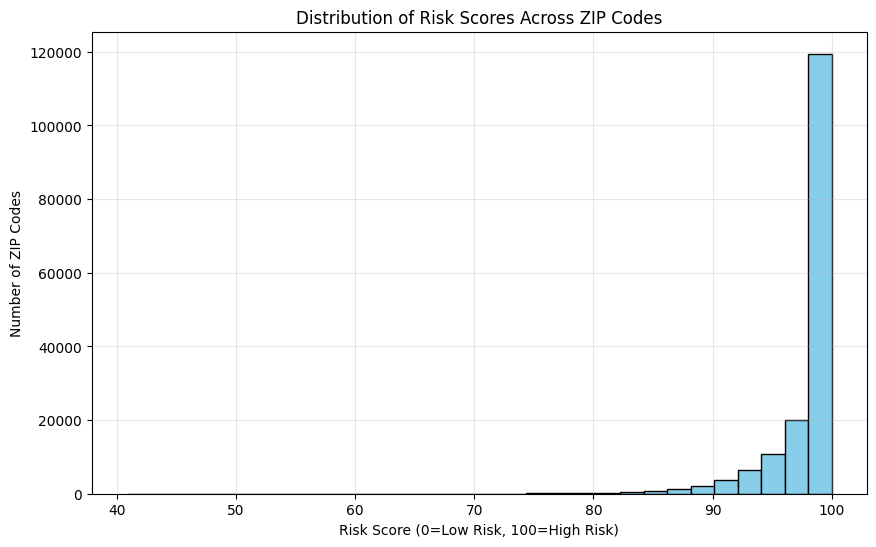

In [16]:
# Visualize risk score distribution
import matplotlib.pyplot as plt
if irs_data is not None:
    plt.figure(figsize=(10,6))
    plt.hist(df['risk_score'], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('Risk Score (0=Low Risk, 100=High Risk)')
    plt.ylabel('Number of ZIP Codes')
    plt.title('Distribution of Risk Scores Across ZIP Codes')
    plt.grid(True, alpha=0.3)
    plt.show()